# Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

# Purpose

A Convolutional Autoencoder (CAE) is an unsupervised deep learning model used for:

Image Compression
Image Reconstruction
Feature Extraction
Dimensionality Reduction

The encoder learns a compressed representation (latent space) of the input image, while the decoder reconstructs the original image from this compressed representation.

In [ ]:
import os # math calcul, access file
import shutil # visualization,  for moving and copies dataset and file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf #

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:


# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

Files in the dataset directory: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [ ]:


# Construct the full path to the CSV file
landmarks_csv_path = os.path.join(path, 'list_landmarks_align_celeba.csv')

# Read the CSV file into a pandas DataFrame
landmarks_df = pd.read_csv(landmarks_csv_path)

# Display the first 5 rows of the DataFrame
display(landmarks_df.head())

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


In [ ]:
import os
import shutil

source_folder= os.path.join(path, "img_align_celeba", "img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder, image),
      destination_folder
      )
  print("Copied", len(image), "image")

Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 10 image
Copied 1

In [ ]:
#Data Preprocessing

IMAGE_SIZE = (64, 64)

BATCH_SIZE = 32

In [ ]:
datagen= ImageDataGenerator(rescale=1./255,
                                   validation_split=0.2)

In [ ]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
#load dataset

validation_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


In [ ]:
# build CAE #encoder
input_img= Input(shape=(64, 64,3))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)


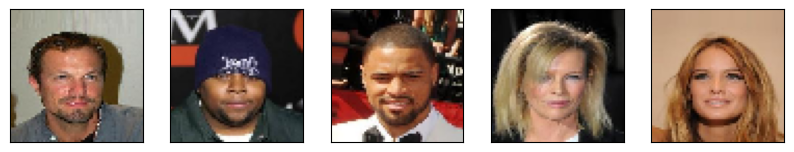

In [ ]:
images,_=next(train_generator)

plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])

In [ ]:
# Encoder
input_img = Input(shape=(64, 64, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)


In [ ]:

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

In [ ]:
# Create Model
autoencoder = Model(inputs=input_img, outputs=decoded)

In [ ]:
# Compile
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Autoencoder
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7907 - loss: 0.5246 - val_accuracy: 0.8136 - val_loss: 0.4949
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8309 - loss: 0.4912 - val_accuracy: 0.8253 - val_loss: 0.4890
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8393 - loss: 0.4880 - val_accuracy: 0.8500 - val_loss: 0.4883
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8454 - loss: 0.4865 - val_accuracy: 0.8473 - val_loss: 0.4855
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8500 - loss: 0.4854 - val_accuracy: 0.8380 - val_loss: 0.4864
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8519 - loss: 0.4846 - val_accuracy: 0.8428 - val_loss: 0.4839
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8548 - loss: 0.4841 - val_accuracy: 0.8633 - val_loss: 0.4839
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8577 - loss: 0.4833 - val_acc

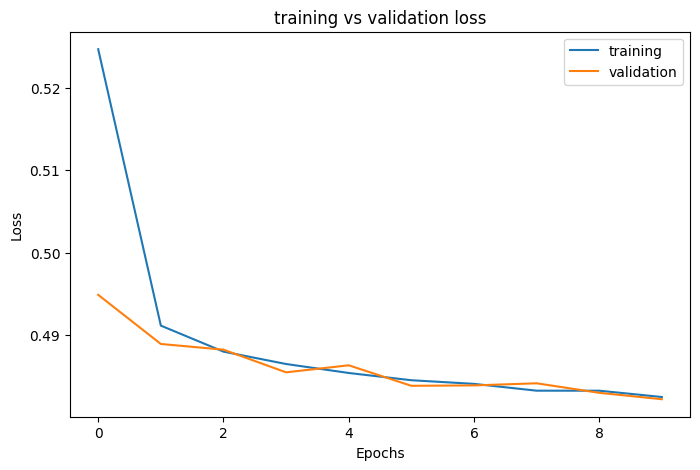

In [ ]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("training vs validation loss")

plt.legend(["training","validation"])
plt.show()

In [ ]:
#Reconstruct Images
images, _ = next(validation_generator)
reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step


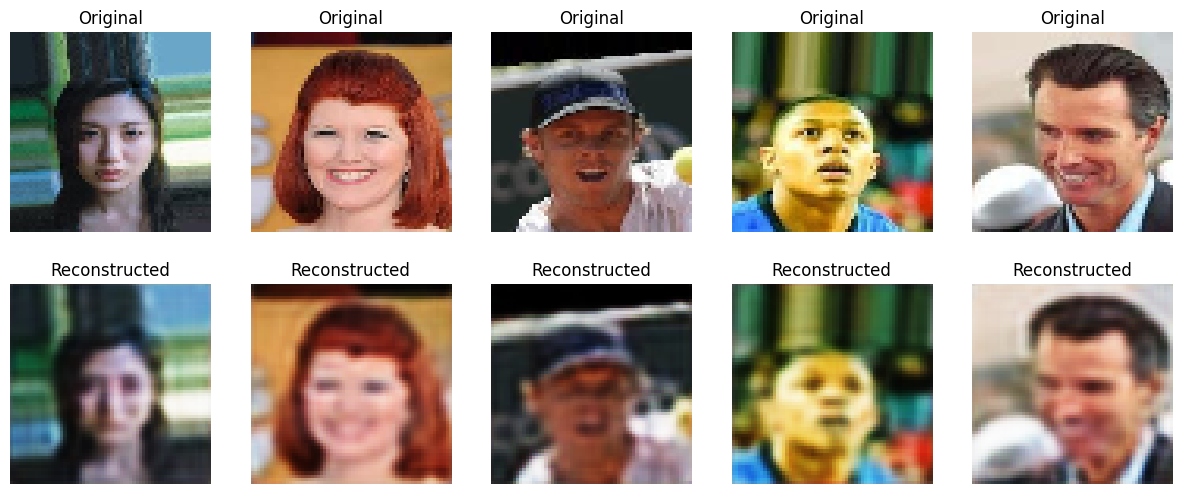

In [ ]:
#Display Results
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed_images[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()